# Lab 12: Data Visualization - Book Dataset Analysis

This notebook generates and analyzes visualizations for the Open Library book dataset. It explores publication trends, rating distributions, and correlations between book metrics.

## Principles of Graphical Excellence
All visualizations in this module are designed following **Edward Tufte's principles of graphical excellence**:
- **Maximizing Data-to-Ink Ratio:** We avoid unnecessary grid lines, 3D effects, or "chartjunk" that doesn't represent data.
- **Integrity:** Axes are clearly labeled, and scales (like the 1-5 rating scale) are consistent with the underlying data source.
- **Clarity and Precision:** We use appropriate chart types (e.g., box plots for distributions, heatmaps for correlations) to ensure the statistical nature of the data is accurately conveyed.

In [1]:
import sys
import os
from pathlib import Path
import pandas as pd

# Add src to path
ROOT = Path(os.getcwd()).parent
sys.path.append(str(ROOT / 'src'))

from visualization.chart_generator import load_data
import visualization.static_charts as static
import visualization.interactive_charts as interactive

# Load cleaned data
data_path = ROOT / 'data' / 'processed' / 'cleaned' / 'cleaned_books.csv'
df = load_data(data_path)

## 1. Static Visualization Analysis

In this section, we display each static chart directly using minimal code. These charts use Matplotlib and Seaborn.

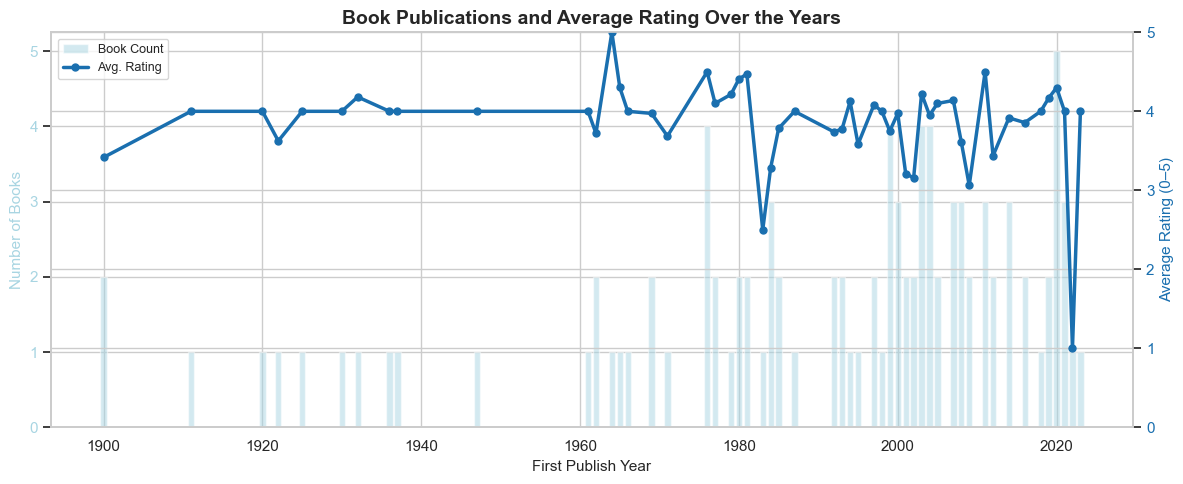

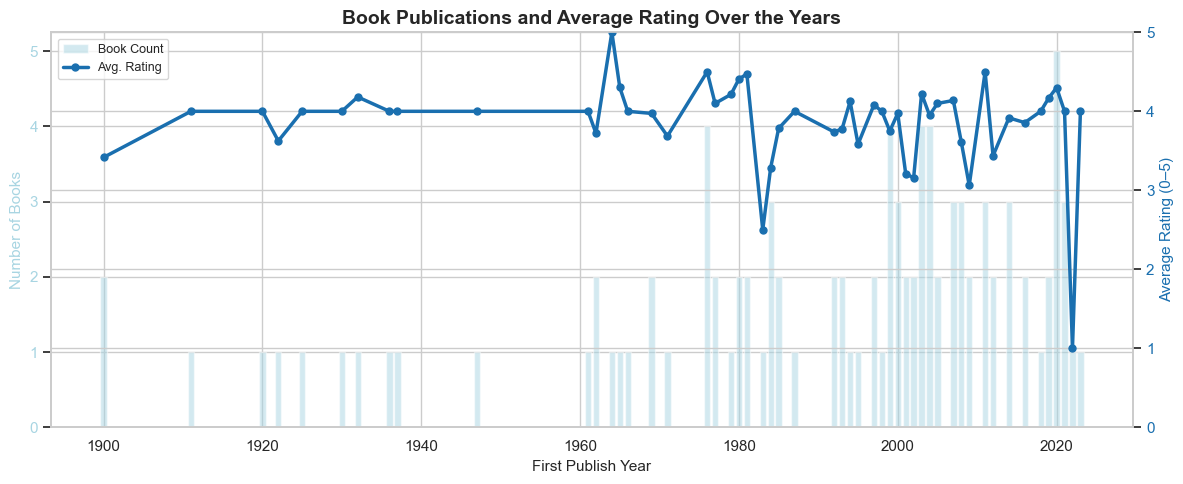

In [2]:
# 1. Book Publications and Average Rating Over the Years
static.plot_avg_rating_over_years(df, save=False);

**Rationale:** A **Line Chart** (avg. rating) overlaid on a **Bar Chart** (count) allows for simultaneous comparison of a continuous trend and discrete volumes. This adheres to Tufte's principle of **integration**.

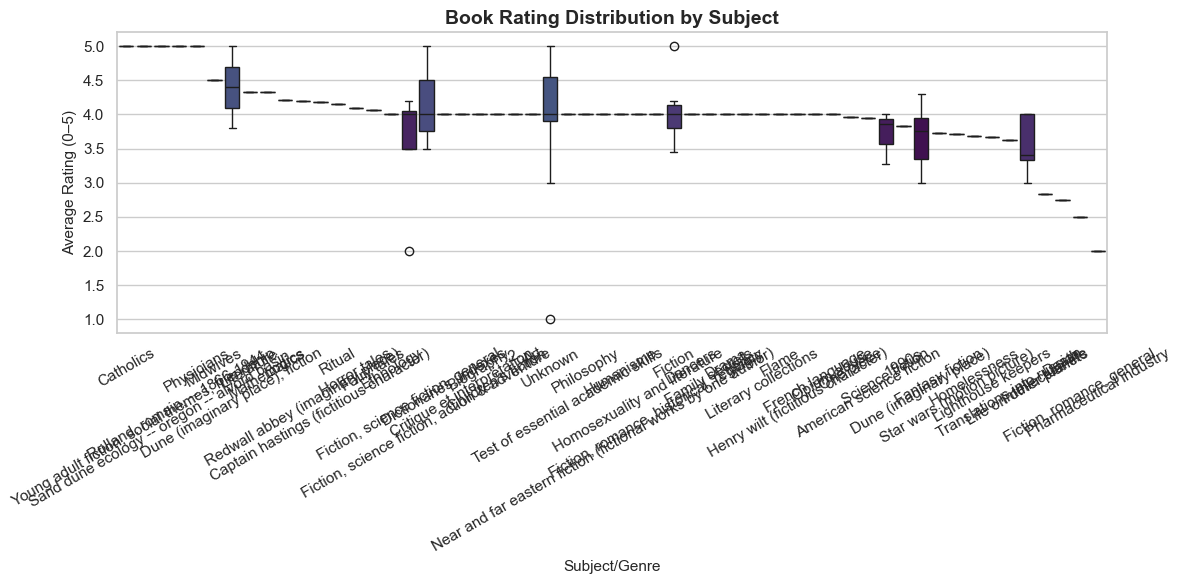

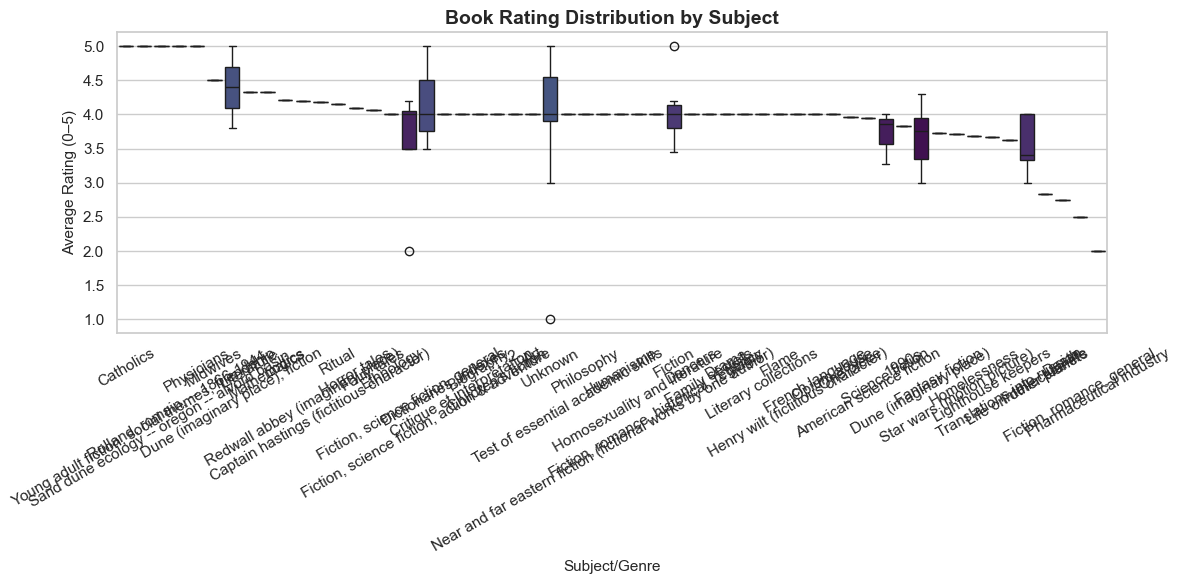

In [3]:
# 2. Book Rating Distribution by Subject
static.plot_subject_rating_boxplot(df, save=False);

**Rationale:** A **Box Plot** is the superior choice for comparing distributions across categories. It maximizes the **data-to-ink ratio** by summarizing five statistical points.

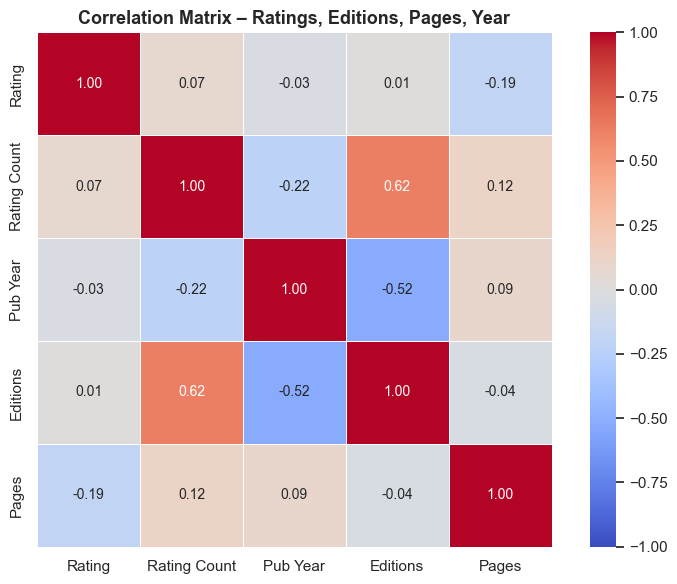

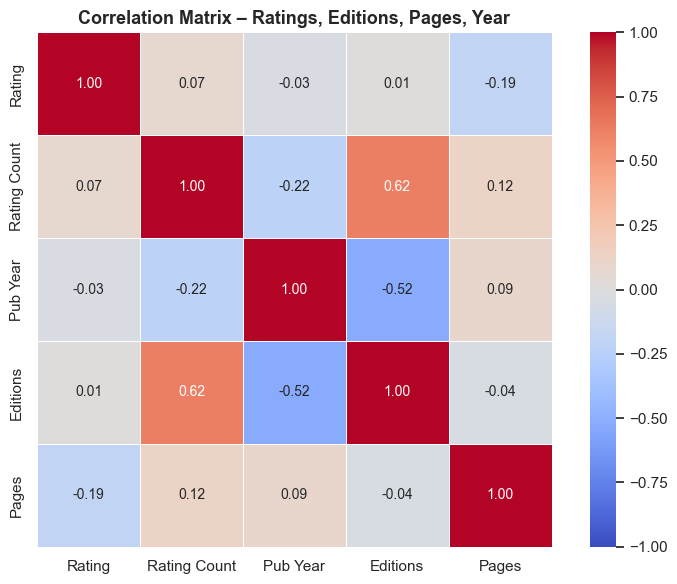

In [4]:
# 3. Correlation Matrix
static.plot_correlation_heatmap(df, save=False);

**Rationale:** A **Heatmap** provides immediate visual recognition of pairwise relationships using a diverging palette.

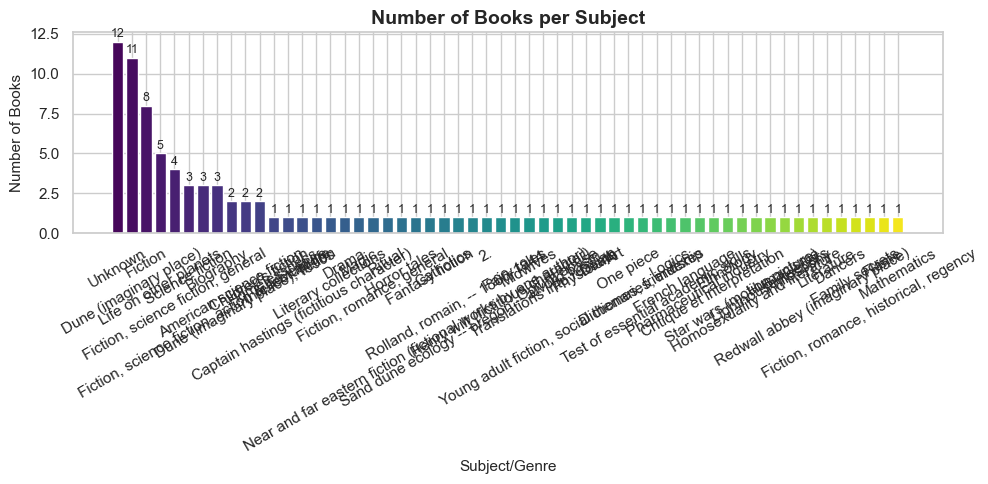

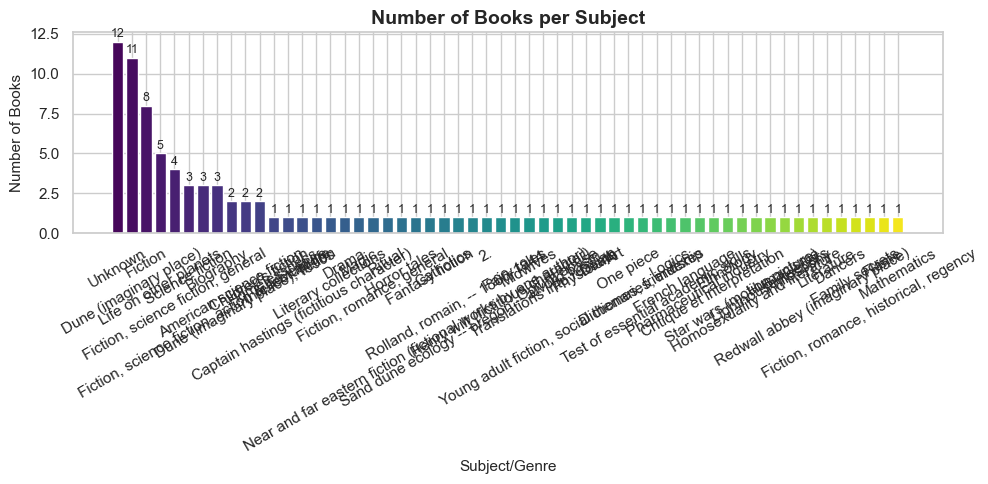

In [5]:
# 4. Number of Books per Subject
static.plot_subject_count_bar(df, save=False)

c:\Users\Laptop\Desktop\Unstructured Data Project\Unstructured-Data-Project\src\visualization\static_charts.py:169: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


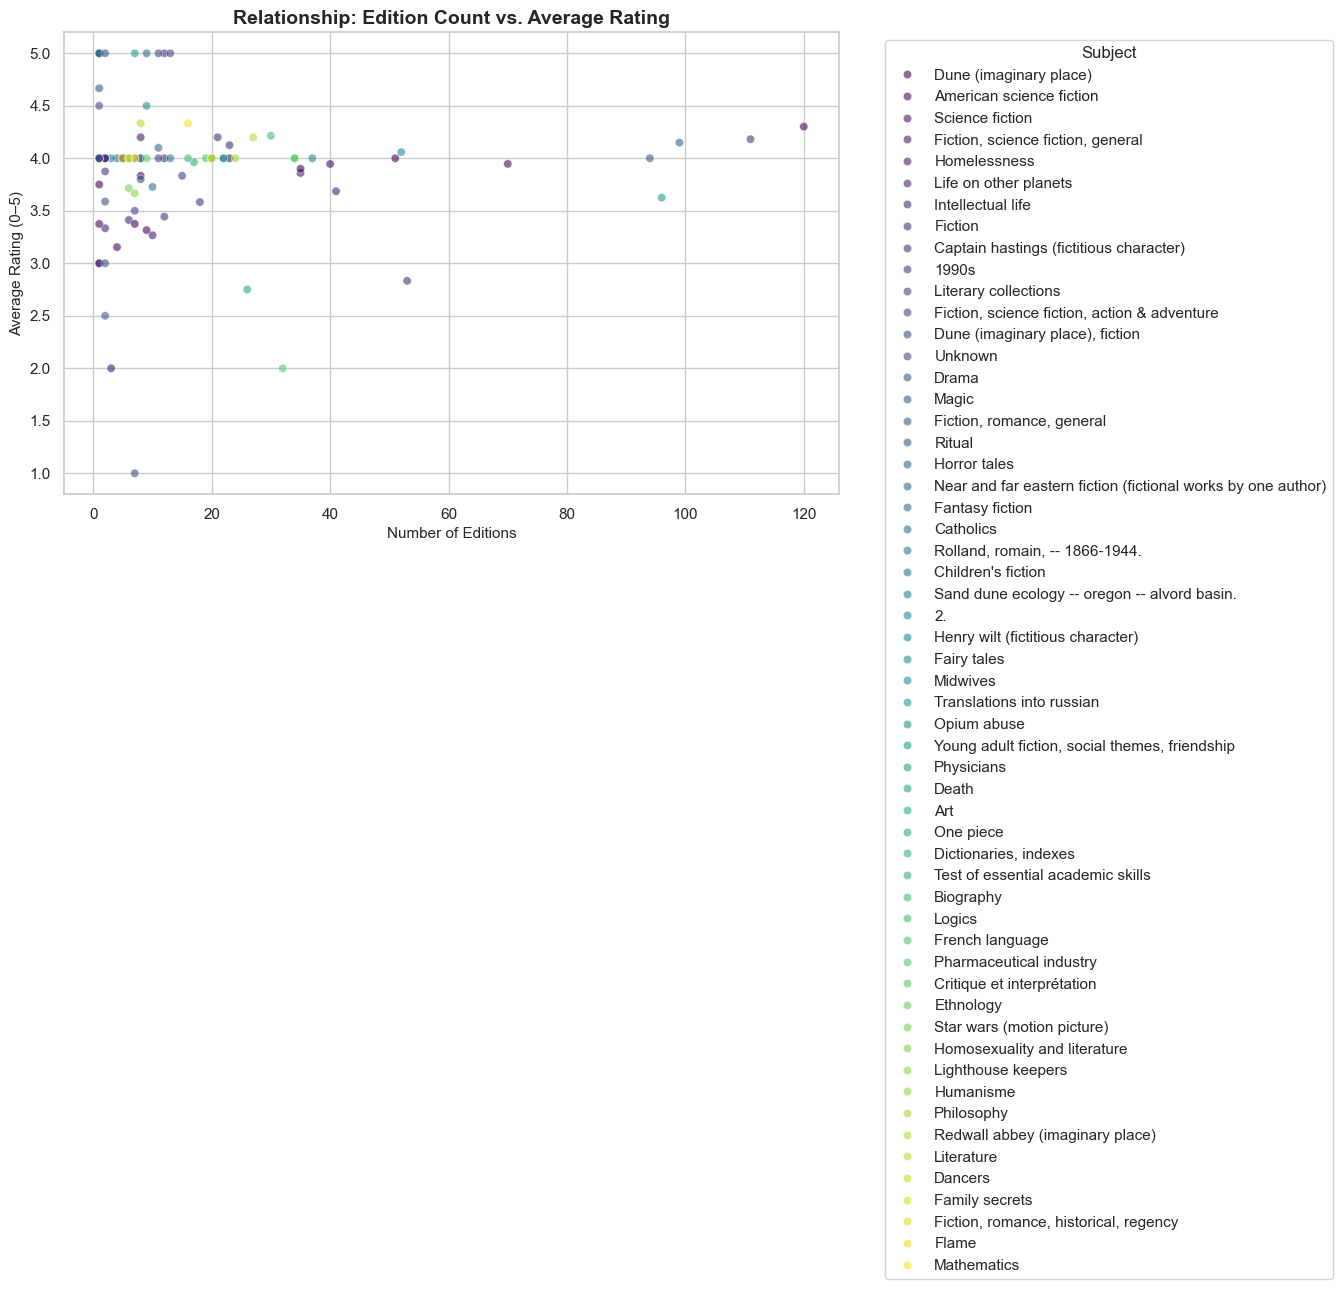

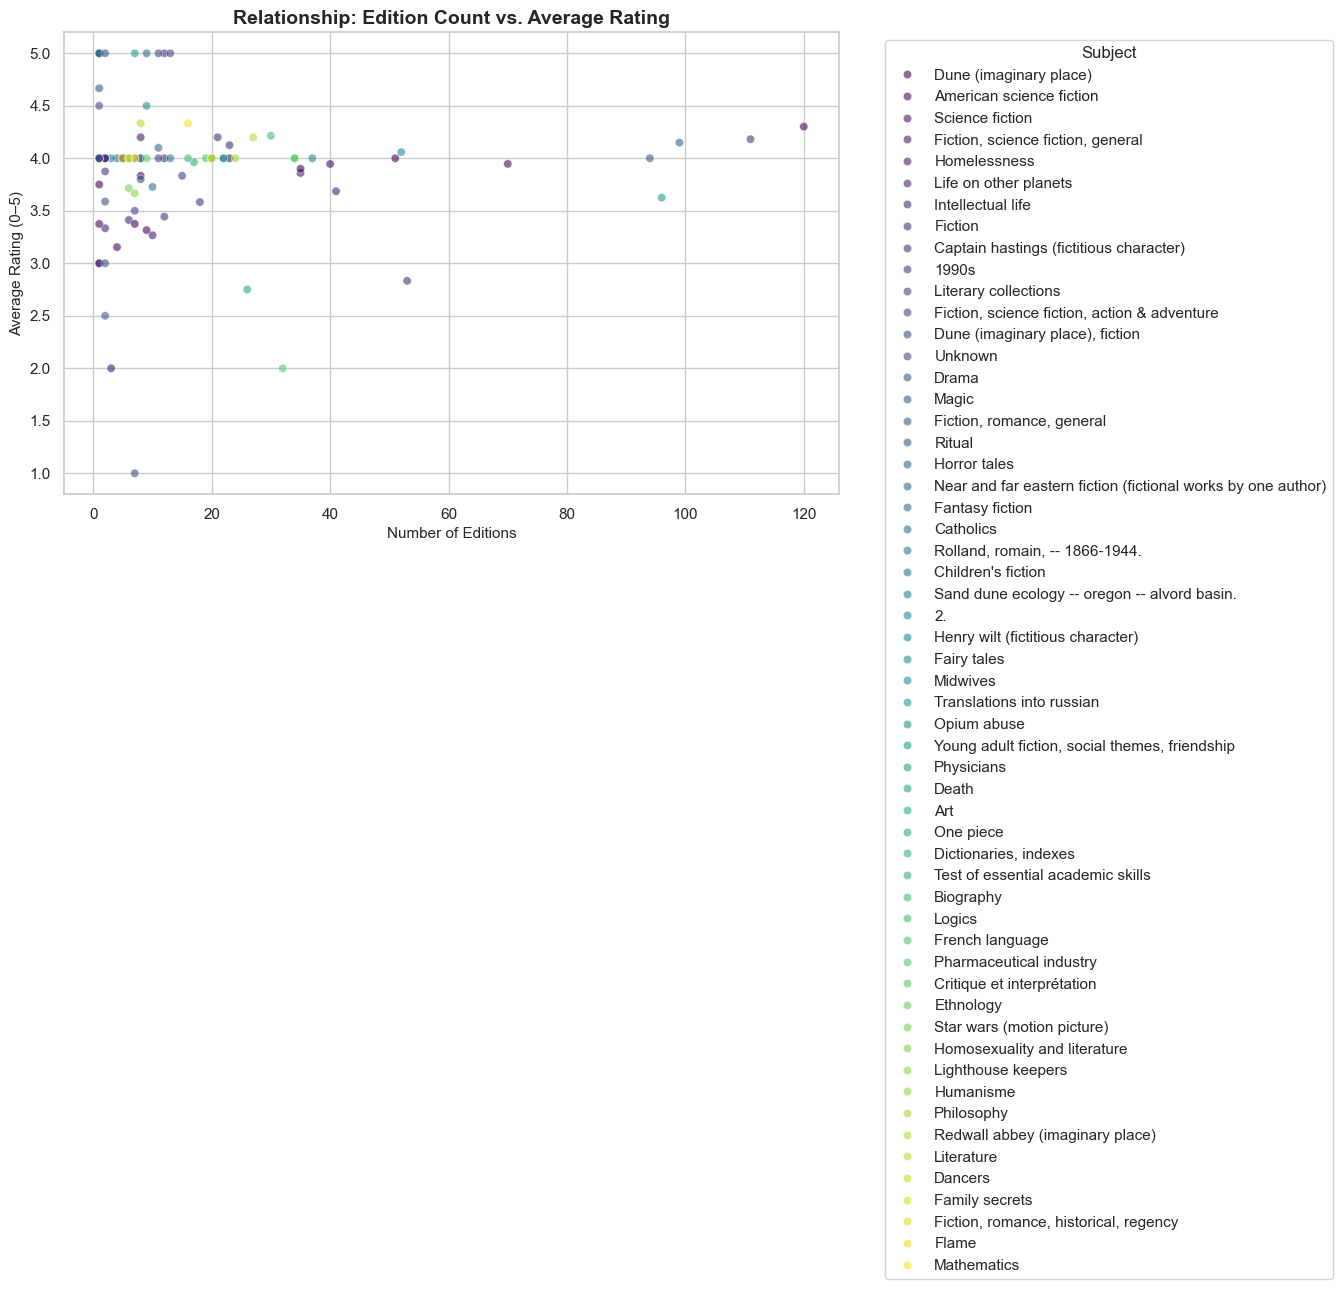

In [6]:
# 5. Edition Count vs. Average Rating
static.plot_rating_vs_edition_count(df, save=False)

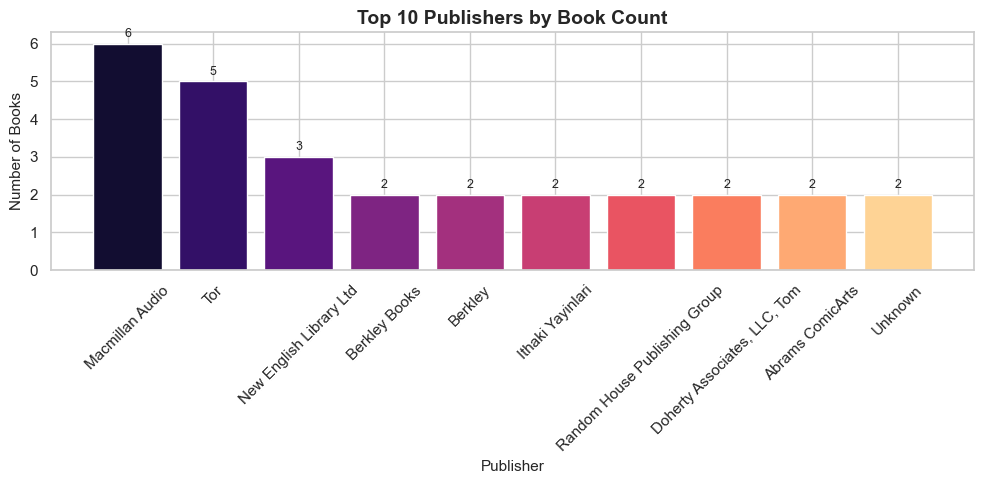

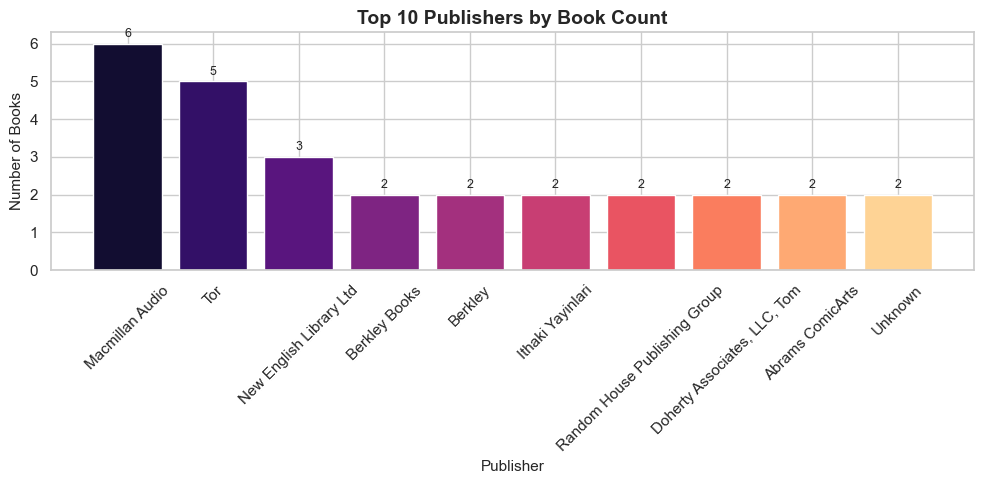

In [7]:
# 6. Top Publishers by Book Count
static.plot_top_publishers_bar(df, save=False)

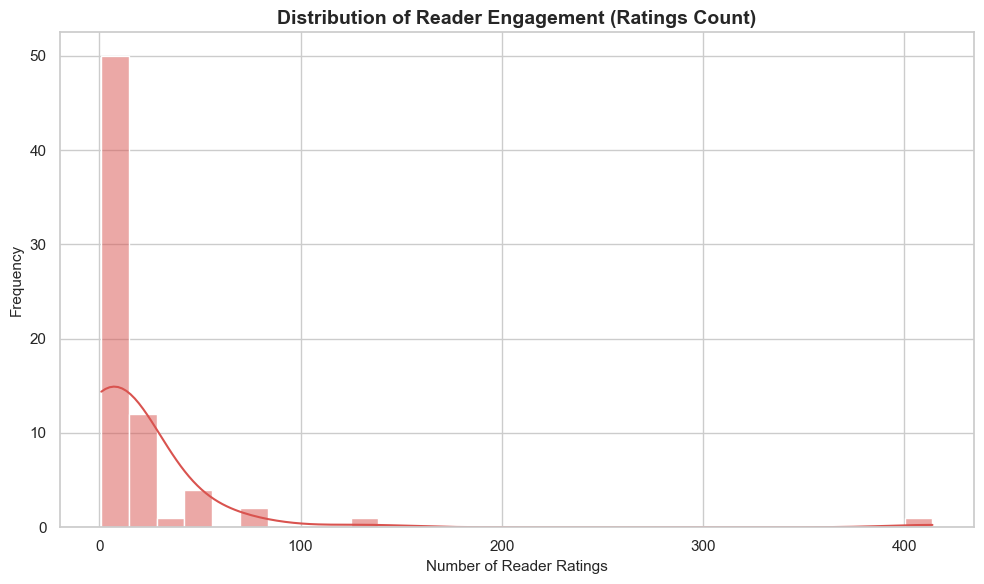

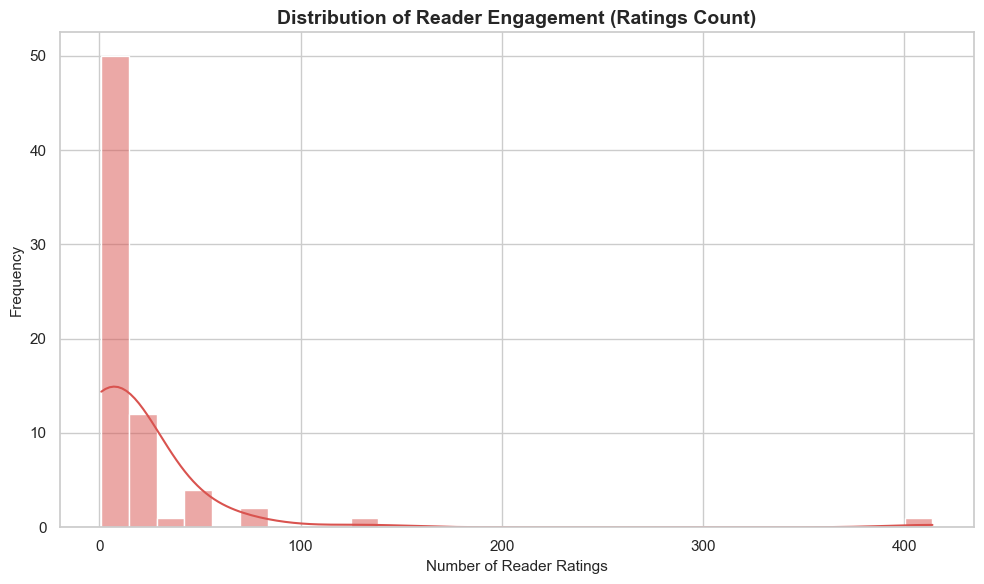

In [8]:
# 7. Reader Engagement Distribution
static.plot_ratings_count_hist(df, save=False)

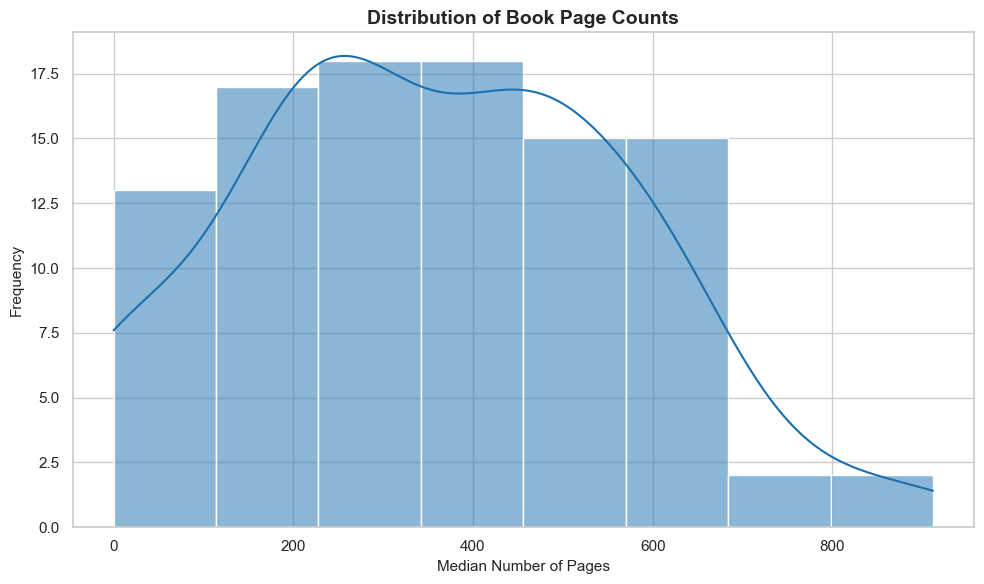

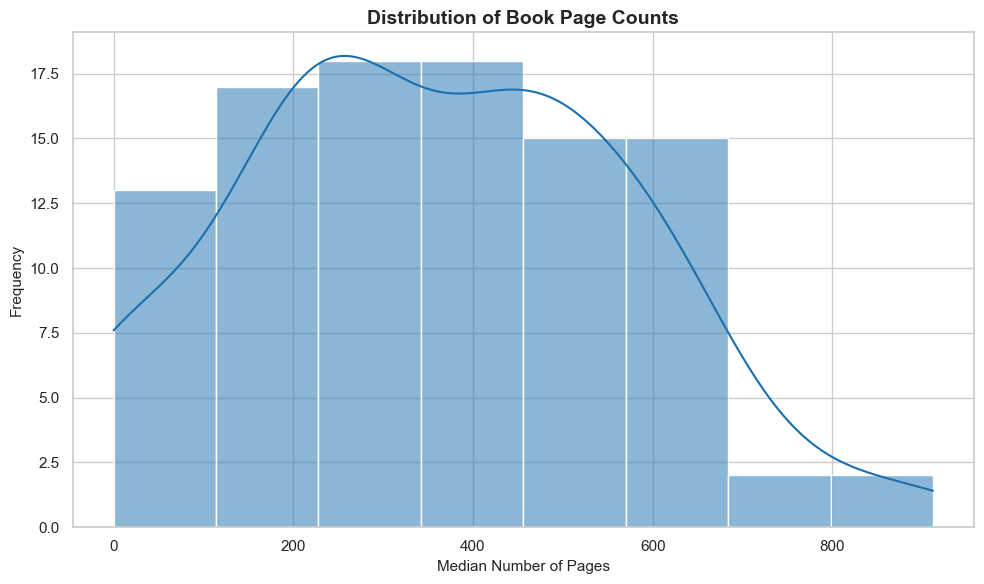

In [9]:
# 8. Book Page Count Distribution
static.plot_pages_distribution(df, save=False)

## 2. Interactive Visualization Analysis

Interactive charts allow for deep exploration. We use Plotly to provide rich tooltips and zooming capabilities.

In [10]:
# 1. Interactive Book Dashboard
fig = interactive.interactive_book_dashboard(df, save=False)
fig.show()

In [11]:
# 2. Editions vs Page Count Explorer
fig = interactive.interactive_editions_vs_pages(df, save=False)
fig.show()

In [12]:
# 3. Top Books by Rating Volume
fig = interactive.interactive_top_books_bar(df, save=False)
fig.show()

In [13]:
# 4. Books Published per Year (Interactive)
fig = interactive.interactive_books_per_year(df, save=False)
fig.show()

In [14]:
# 5. Subject Rating Distribution (Interactive)
fig = interactive.interactive_subject_boxplot(df, save=False)
fig.show()

## 3. Q&A Documentation

In this section, we answer key questions about the dataset using pandas analytics.

In [15]:
# Q1: Which subject has the highest average rating?
subject_ratings = df.groupby('genres')['rating'].mean().sort_values(ascending=False)
print("Highest Rated Subjects:")
print(subject_ratings.head(5))

Highest Rated Subjects:
genres
Catholics                                         5.0
Young adult fiction, social themes, friendship    5.0
Sand dune ecology -- oregon -- alvord basin.      5.0
Rolland, romain, -- 1866-1944.                    5.0
Physicians                                        5.0
Name: rating, dtype: float64


In [16]:
# Q2: Is there a significant correlation between page count and reader rating?
correlation = df['number_of_pages_median'].corr(df['rating'])
print(f"Correlation between Page Count and Rating: {correlation:.4f}")

Correlation between Page Count and Rating: -0.1888


In [17]:
# Q3: What are the top 5 most engaged-with books (highest rating count)?
top_engaged = df.nlargest(5, 'ratings_count')[['title', 'author_name', 'ratings_count', 'rating']]
print("Top 5 Most Engaged Books:")
display(top_engaged)

Top 5 Most Engaged Books:


,title,author_name,ratings_count,rating
0,Dune,Frank Herbert,414.0,4.301932
1,Dune Messiah,Frank Herbert,132.0,3.946970
4,God Emperor Of Dune,Frank Herbert,74.0,3.945946
70,"Gödel, Escher, Bach",Douglas R. Hofstadter,70.0,4.214286
7,Go Ask Alice,Beatrice Sparks,51.0,3.686275


In [18]:
# Q4: How has the average book length (pages) changed over the decades?
df['decade'] = (df['first_publish_year'] // 10) * 10
decade_pages = df.groupby('decade')['number_of_pages_median'].mean()
print("Average Page Count by Decade:")
print(decade_pages.dropna())

Average Page Count by Decade:
decade
1890    495.000000
1900    357.000000
1910    343.000000
1920    110.333333
1930    244.250000
1940    192.000000
1960    275.625000
1970    399.875000
1980    363.909091
1990    420.923077
2000    461.200000
2010    371.230769
2020    135.200000
Name: number_of_pages_median, dtype: float64
